# Sistem Prediksi Harga Rica (Cabai Rawit Merah) — Kota Manado
**Pipeline lengkap:** Data Engineering → Feature Engineering → Analisis → Pemodelan → Evaluasi

| | |
|---|---|
| **Sumber Data** | PIHPS (Pasar Bersehati & Pinasungkulan) + BMKG Stasiun Manado |
| **Rentang Waktu** | Januari 2020 – Maret 2026 |
| **Model Terpilih** | Random Forest Regressor |
| **MAPE Final** | 5.93% |

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import xgboost as xgb

## 2. Data Ingestion & Cleaning

### 2.1 Dataset Harga Pangan (PIHPS)
Konsolidasi 5 file Excel laporan harga PIHPS. Setiap file di-unpivot dari format tabel melebar
menjadi format time-series. Harga yang kosong di hari libur/weekend diisi dengan forward fill.

In [2]:
# [Data Ingestion] Penggabungan & pembersihan data harga pangan
path = "C:\\Users\\User\\tkti_dataset\\dataset_pangan"
all_files = glob.glob(os.path.join(path, "*xlsx"))

list_df_pangan = []
print(f"Menemukan {len(all_files)} file. Memulai proses pembersihan...")

for filename in all_files:
    try:
        df_raw = pd.read_excel(filename)
        df_raw['Komoditas (Rp)'] = df_raw['Komoditas (Rp)'].astype(str).str.strip()
        df_filtered = df_raw[df_raw['Komoditas (Rp)'] == 'Cabai Rawit Merah'].copy()
        if df_filtered.empty:
            print(f"Peringatan: Tidak menemukan baris 'Cabai Rawit Merah' di {os.path.basename(filename)}")
            continue
        if 'No' in df_filtered.columns:
            df_filtered = df_filtered.drop(columns=['No'])
        df_melted = df_filtered.melt(
            id_vars=['Komoditas (Rp)'],
            var_name='Tanggal',
            value_name='Harga'
        )
        list_df_pangan.append(df_melted)
        print(f"Berhasil unpivot: {os.path.basename(filename)} ({len(df_melted)} baris)")
    except Exception as e:
        print(f"Gagal memproses {os.path.basename(filename)}: {e}")

if list_df_pangan:
    df_pangan_final = pd.concat(list_df_pangan, axis=0, ignore_index=True)
    df_pangan_final['Tanggal'] = df_pangan_final['Tanggal'].astype(str).str.replace(' ', '', regex=False)
    df_pangan_final['Tanggal'] = pd.to_datetime(df_pangan_final['Tanggal'], dayfirst=True, errors='coerce')
    df_pangan_final['Harga'] = df_pangan_final['Harga'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    df_pangan_final['Harga'] = pd.to_numeric(df_pangan_final['Harga'].replace('-', np.nan), errors='coerce')
    df_pangan_final = df_pangan_final.sort_values('Tanggal')
    df_pangan_final['Harga'] = df_pangan_final['Harga'].ffill()
    df_pangan_final = df_pangan_final.dropna(subset=['Tanggal', 'Harga'])
    df_pangan_final = df_pangan_final[['Tanggal', 'Harga']]
    df_pangan_final.to_csv('data_pangan_merge_raw.csv', index=False)
    print(f"\nTotal baris data pangan: {len(df_pangan_final)}")
    print(df_pangan_final.head())

Menemukan 5 file. Memulai proses pembersihan...
Berhasil unpivot: Tabel Harga 2020.xlsx (262 baris)
Berhasil unpivot: Tabel Harga 2021.xlsx (261 baris)
Berhasil unpivot: Tabel Harga 2022.xlsx (260 baris)
Berhasil unpivot: Tabel Harga 2023-2024.xlsx (522 baris)
Berhasil unpivot: Tabel Harga 2025-Mar 2026.xlsx (325 baris)

Total baris data pangan: 1629
     Tanggal  Harga
1 2020-01-02  39.50
2 2020-01-03  39.50
3 2020-01-06  37.75
4 2020-01-07  37.75
5 2020-01-08  37.75


### 2.2 Dataset Cuaca BMKG
Konsolidasi 75 file Excel laporan iklim BMKG (~9.120 baris mentah). Duplikat tanggal
dari dua stasiun berbeda digabung dengan metode rata-rata (agregasi mean).

In [4]:
# [Data Ingestion] Penggabungan & deduplikasi data cuaca BMKG
path = "C:\\Users\\User\\tkti_dataset"
all_files = glob.glob(os.path.join(path, "*xlsx"))

list_df = []
print(f"Menemukan {len(all_files)} file. Memulai proses pembersihan...")

for filename in all_files:
    try:
        df_temp = pd.read_excel(filename, header=7)
        df_temp.columns = [str(c).strip() for c in df_temp.columns]
        cols_needed = ['TANGGAL', 'TAVG', 'RH_AVG', 'RR']
        if all(c in df_temp.columns for c in cols_needed):
            list_df.append(df_temp[cols_needed])
    except Exception as e:
        print(f"Gagal memproses {os.path.basename(filename)}: {e}")

if list_df:
    df_raw_concat = pd.concat(list_df, axis=0, ignore_index=True)
    df_raw_concat['TANGGAL'] = pd.to_datetime(df_raw_concat['TANGGAL'], dayfirst=True, errors='coerce')
    df_raw_concat = df_raw_concat.dropna(subset=['TANGGAL'])

   
    for col in ['TAVG', 'RH_AVG', 'RR']:
        df_raw_concat[col] = pd.to_numeric(df_raw_concat[col], errors='coerce')

    df_cuaca_clean = df_raw_concat.groupby('TANGGAL').agg({
        'TAVG': 'mean',
        'RH_AVG': 'mean',
        'RR': 'mean'
    }).reset_index()
    df_cuaca_clean = df_cuaca_clean.sort_values('TANGGAL')
    df_cuaca_clean.to_csv('data_cuaca_merge_clean.csv', index=False)

    print(f"Total baris mentah: {len(df_raw_concat)}")
    print(f"Total baris unik setelah deduplikasi: {len(df_cuaca_clean)}")
    print(f"Rentang: {df_cuaca_clean['TANGGAL'].min().date()} s/d {df_cuaca_clean['TANGGAL'].max().date()}")
    print(df_cuaca_clean.head())

Menemukan 75 file. Memulai proses pembersihan...
Total baris mentah: 2280
Total baris unik setelah deduplikasi: 2280
Rentang: 2020-01-01 s/d 2026-03-31
     TANGGAL  TAVG  RH_AVG   RR
0 2020-01-01  23.8    82.0  0.2
1 2020-01-02   NaN     NaN  0.0
2 2020-01-03  22.1    92.0  0.5
3 2020-01-04  22.2    94.0  7.6
4 2020-01-05  22.0    94.0  4.3


## 3. Pre-processing & Feature Engineering Awal

Kedua dataset digabung ke master calendar harian. Missing values cuaca diisi dengan
interpolasi linear; harga weekend dengan forward fill. Fitur awal yang dibuat:
`Is_Hari_Raya`, `Harga_Lag_1`, `Harga_Lag_7`, `Bulan`, `Tahun`, `Hari_ke`.

In [5]:
# [Pre-processing] Merge, imputasi, dan feature engineering awal
df_cuaca = pd.read_csv('data_cuaca_merge_clean.csv')
df_pangan = pd.read_csv('data_pangan_merge_raw.csv')

df_cuaca['Tanggal'] = pd.to_datetime(df_cuaca['TANGGAL'])
df_pangan['Tanggal'] = pd.to_datetime(df_pangan['Tanggal'])

start_date = df_cuaca['Tanggal'].min()
end_date   = df_cuaca['Tanggal'].max()
master_calendar = pd.DataFrame({'Tanggal': pd.date_range(start=start_date, end=end_date)})

df_final = pd.merge(master_calendar, df_cuaca.drop(columns=['TANGGAL']), on='Tanggal', how='left')
df_final = pd.merge(df_final, df_pangan, on='Tanggal', how='left')

df_final[['TAVG', 'RH_AVG', 'RR']] = df_final[['TAVG', 'RH_AVG', 'RR']].interpolate(method='linear')
df_final['Harga'] = df_final['Harga'].ffill()

df_final['Bulan']   = df_final['Tanggal'].dt.month
df_final['Hari_ke'] = df_final['Tanggal'].dt.dayofweek
df_final['Tahun']   = df_final['Tanggal'].dt.year

def is_holiday_manado(row):
    if (row.month == 12 and row.day in [24, 25, 31]) or (row.month == 1 and row.day == 1):
        return 1
    return 0

df_final['Is_Hari_Raya'] = df_final['Tanggal'].apply(is_holiday_manado)
df_final['Harga_Lag_1']  = df_final['Harga'].shift(1)
df_final['Harga_Lag_7']  = df_final['Harga'].shift(7)

df_final = df_final.dropna()
df_final.to_csv('clean_dataset_rica_manado_final.csv', index=False)

print(f"Total baris: {len(df_final)}")
print(f"Kolom: {df_final.columns.tolist()}")
print(df_final.head())

Total baris: 2274
Kolom: ['Tanggal', 'TAVG', 'RH_AVG', 'RR', 'Harga', 'Bulan', 'Hari_ke', 'Tahun', 'Is_Hari_Raya', 'Harga_Lag_1', 'Harga_Lag_7']
      Tanggal  TAVG  RH_AVG    RR  Harga  Bulan  Hari_ke  Tahun  Is_Hari_Raya  \
8  2020-01-09  23.2    91.0   0.9  37.25      1        3   2020             0   
9  2020-01-10  22.4    94.0   0.5  37.25      1        4   2020             0   
10 2020-01-11  23.2    91.0   4.2  37.25      1        5   2020             0   
11 2020-01-12  22.0    90.0  10.4  37.25      1        6   2020             0   
12 2020-01-13  23.9    79.0   0.5  47.00      1        0   2020             0   

    Harga_Lag_1  Harga_Lag_7  
8         37.75        39.50  
9         37.25        39.50  
10        37.25        39.50  
11        37.25        39.50  
12        37.25        37.75  


## 4. Feature Engineering Lanjutan

Penambahan fitur rolling, volatilitas, lag bulanan, dan lag curah hujan 44 hari.
`RR_Lag_44` ditemukan dari analisis lag correlation sebagai lag dengan korelasi
terkuat antara curah hujan dan harga rica.

In [6]:
# [Feature Engineering] Rolling, volatilitas, lag bulanan, dan RR_Lag_44
df = pd.read_csv('clean_dataset_rica_manado_final.csv')
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.sort_values('Tanggal').reset_index(drop=True)

df['Rolling_Mean_7']  = df['Harga'].rolling(window=7).mean()
df['Rolling_Mean_14'] = df['Harga'].rolling(window=14).mean()
df['Harga_Std_7']     = df['Harga'].rolling(window=7).std()
df['Harga_Lag_30']    = df['Harga'].shift(30)
df['RR_Lag_44']       = df['RR'].shift(44)

df = df.dropna().reset_index(drop=True)

print(f"Total baris setelah penambahan fitur: {len(df)}")
print(f"Kolom final: {df.columns.tolist()}")

Total baris setelah penambahan fitur: 2230
Kolom final: ['Tanggal', 'TAVG', 'RH_AVG', 'RR', 'Harga', 'Bulan', 'Hari_ke', 'Tahun', 'Is_Hari_Raya', 'Harga_Lag_1', 'Harga_Lag_7', 'Rolling_Mean_7', 'Rolling_Mean_14', 'Harga_Std_7', 'Harga_Lag_30', 'RR_Lag_44']


## 5. Analisis Korelasi Curah Hujan vs Harga

Temuan utama:
- Korelasi langsung hampir nol (r = 0.007) — curah hujan tidak langsung mempengaruhi harga
- Lag terkuat ditemukan di **44 hari** — rantai kausalitas: hujan → gagal panen → suplai turun → harga naik
- Harga memuncak di Mei & Desember, bertepatan dengan musim hujan tinggi di Manado

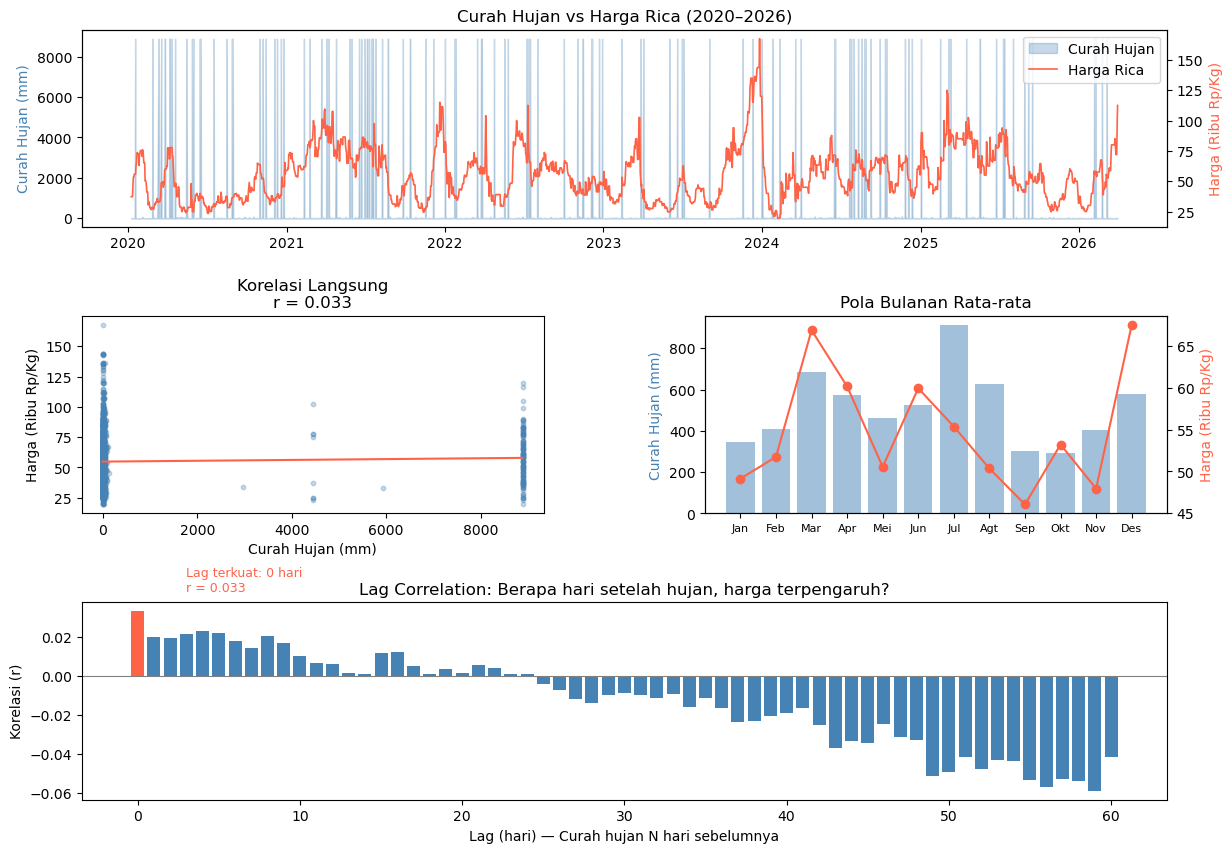

In [7]:
# [Analisis] Korelasi curah hujan vs harga dengan lag correlation
df_ori = pd.read_csv('clean_dataset_rica_manado_final.csv')
df_ori['Tanggal'] = pd.to_datetime(df_ori['Tanggal'])
df_ori = df_ori.sort_values('Tanggal').dropna(subset=['RR', 'Harga'])

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1  = fig.add_subplot(gs[0, :])
ax1b = ax1.twinx()
ax1.fill_between(df_ori['Tanggal'], df_ori['RR'], alpha=0.3, color='steelblue', label='Curah Hujan')
ax1b.plot(df_ori['Tanggal'], df_ori['Harga'], color='tomato', linewidth=1.2, label='Harga Rica')
ax1.set_ylabel('Curah Hujan (mm)', color='steelblue')
ax1b.set_ylabel('Harga (Ribu Rp/Kg)', color='tomato')
ax1.set_title('Curah Hujan vs Harga Rica (2020–2026)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(df_ori['RR'], df_ori['Harga'], alpha=0.3, s=10, color='steelblue')
z      = np.polyfit(df_ori['RR'], df_ori['Harga'], 1)
p      = np.poly1d(z)
x_line = np.linspace(df_ori['RR'].min(), df_ori['RR'].max(), 100)
ax2.plot(x_line, p(x_line), color='tomato', linewidth=1.5)
corr = df_ori['RR'].corr(df_ori['Harga'])
ax2.set_xlabel('Curah Hujan (mm)')
ax2.set_ylabel('Harga (Ribu Rp/Kg)')
ax2.set_title(f'Korelasi Langsung\nr = {corr:.3f}')

ax3  = fig.add_subplot(gs[1, 1])
bulanan    = df_ori.groupby('Bulan').agg({'RR': 'mean', 'Harga': 'mean'}).reset_index()
nama_bulan = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agt','Sep','Okt','Nov','Des']
x   = np.arange(12)
ax3b = ax3.twinx()
ax3.bar(x, bulanan['RR'], color='steelblue', alpha=0.5)
ax3b.plot(x, bulanan['Harga'], color='tomato', marker='o', linewidth=1.5)
ax3.set_xticks(x)
ax3.set_xticklabels(nama_bulan, fontsize=8)
ax3.set_ylabel('Curah Hujan (mm)', color='steelblue')
ax3b.set_ylabel('Harga (Ribu Rp/Kg)', color='tomato')
ax3.set_title('Pola Bulanan Rata-rata')

ax4       = fig.add_subplot(gs[2, :])
lags      = range(0, 61)
lag_corrs = [df_ori['Harga'].corr(df_ori['RR'].shift(lag)) for lag in lags]
colors    = ['tomato' if c == max(lag_corrs) else 'steelblue' for c in lag_corrs]
ax4.bar(lags, lag_corrs, color=colors)
ax4.axhline(0, color='gray', linewidth=0.8)
ax4.set_xlabel('Lag (hari) — Curah hujan N hari sebelumnya')
ax4.set_ylabel('Korelasi (r)')
ax4.set_title('Lag Correlation: Berapa hari setelah hujan, harga terpengaruh?')
best_lag = lags[lag_corrs.index(max(lag_corrs))]
ax4.annotate(f'Lag terkuat: {best_lag} hari\nr = {max(lag_corrs):.3f}',
             xy=(best_lag, max(lag_corrs)),
             xytext=(best_lag+3, max(lag_corrs)+0.01),
             fontsize=9, color='tomato')

plt.savefig('analisis_curah_hujan_harga.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Data Splitting & Feature Scaling

Split kronologis 80/20 — tidak menggunakan shuffle agar urutan waktu tetap terjaga.
MinMaxScaler di-fit **hanya di training set** untuk menghindari data leakage.

In [8]:
# [Modelling] Split kronologis dan feature scaling
feature_cols = [
    'RR', 'TAVG', 'RH_AVG',
    'RR_Lag_44',
    'Harga_Lag_1', 'Harga_Lag_7', 'Harga_Lag_30',
    'Rolling_Mean_7', 'Rolling_Mean_14', 'Harga_Std_7',
    'Bulan', 'Tahun', 'Is_Hari_Raya'
]

split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test  = df.iloc[split_idx:].copy()

print(f"Train: {len(train)} baris | {train['Tanggal'].min().date()} s/d {train['Tanggal'].max().date()}")
print(f"Test:  {len(test)} baris  | {test['Tanggal'].min().date()} s/d {test['Tanggal'].max().date()}")

scaler = MinMaxScaler()
train[feature_cols] = scaler.fit_transform(train[feature_cols])
test[feature_cols]  = scaler.transform(test[feature_cols])

X_train, y_train = train[feature_cols], train['Harga']
X_test,  y_test  = test[feature_cols],  test['Harga']

Train: 1784 baris | 2020-02-22 s/d 2025-01-09
Test:  446 baris  | 2025-01-10 s/d 2026-03-31


## 7. Eksperimen Model

Tiga model diuji: XGBoost (default), XGBoost (tuned dengan GridSearchCV + TimeSeriesSplit),
dan Random Forest. Metrik evaluasi: RMSE dan MAPE.

### 7.1 XGBoost (Default)

In [9]:
# [Modelling] XGBoost dengan parameter default
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
xgb_preds = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mape = np.mean(np.abs((y_test - xgb_preds) / y_test)) * 100

print(f"XGBoost Default → RMSE: Rp {xgb_rmse*1000:,.0f} | MAPE: {xgb_mape:.2f}%")

[0]	validation_0-rmse:19.75994
[50]	validation_0-rmse:6.18033
[100]	validation_0-rmse:6.09941
[150]	validation_0-rmse:6.07254
[200]	validation_0-rmse:6.07394
[250]	validation_0-rmse:6.06808
[299]	validation_0-rmse:6.05726
XGBoost Default → RMSE: Rp 6,057 | MAPE: 6.85%


### 7.2 XGBoost (Hyperparameter Tuning)

In [10]:
# [Modelling] XGBoost dengan GridSearchCV + TimeSeriesSplit
param_grid = {
    'n_estimators': [300, 500],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=5)
xgb_tune = xgb.XGBRegressor(random_state=42, verbosity=0)

grid_search = GridSearchCV(
    estimator=xgb_tune,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print(f"Parameter terbaik: {grid_search.best_params_}")

best_xgb   = grid_search.best_estimator_
best_preds = best_xgb.predict(X_test)
best_rmse  = np.sqrt(mean_squared_error(y_test, best_preds))
best_mape  = np.mean(np.abs((y_test - best_preds) / y_test)) * 100

print(f"XGBoost Tuned → RMSE: Rp {best_rmse*1000:,.0f} | MAPE: {best_mape:.2f}%")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Parameter terbaik: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.7}
XGBoost Tuned → RMSE: Rp 6,054 | MAPE: 7.60%


### 7.3 Random Forest

In [13]:
# [Modelling] Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    n_jobs=1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mape = np.mean(np.abs((y_test - rf_preds) / y_test)) * 100

print(f"Random Forest → RMSE: Rp {rf_rmse*1000:,.0f} | MAPE: {rf_mape:.2f}%")

Random Forest → RMSE: Rp 6,060 | MAPE: 6.62%


## 8. Perbandingan Model & Kesimpulan

Random Forest terpilih sebagai model final karena menghasilkan MAPE terendah.
Temuan: pada dataset berukuran sedang dengan fitur lag yang dominan, model ensemble
sederhana dapat mengungguli gradient boosting meskipun tanpa tuning.

In [14]:
# [Evaluasi] Tabel perbandingan seluruh model
print(f"{'='*52}")
print(f"{'Model':<32} {'MAPE':>8} {'RMSE':>12}")
print(f"{'='*52}")
print(f"{'XGBoost (default)':<32} {f'{xgb_mape:.2f}%':>8} {f'Rp {xgb_rmse*1000:,.0f}':>12}")
print(f"{'XGBoost (tuned)':<32} {f'{best_mape:.2f}%':>8} {f'Rp {best_rmse*1000:,.0f}':>12}")
print(f"{'Random Forest ✓ (model final)':<32} {f'{rf_mape:.2f}%':>8} {f'Rp {rf_rmse*1000:,.0f}':>12}")
print(f"{'='*52}")

Model                                MAPE         RMSE
XGBoost (default)                   6.85%     Rp 6,057
XGBoost (tuned)                     7.60%     Rp 6,054
Random Forest ✓ (model final)       6.62%     Rp 6,060


## 9. Visualisasi Prediksi vs Aktual (Model Final)

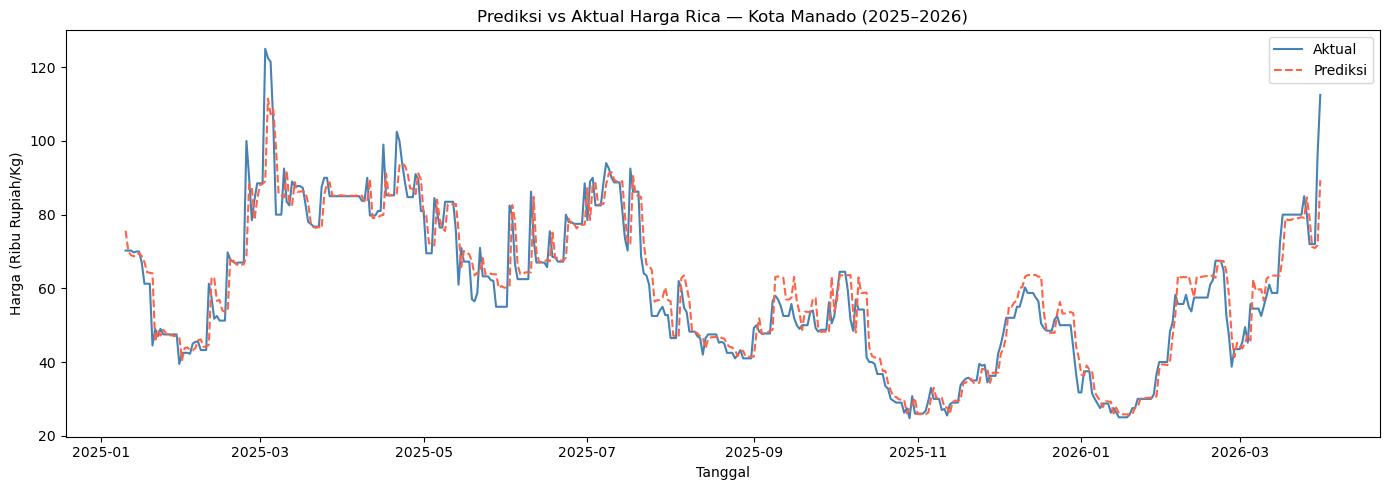

RMSE : Rp 6,060
MAPE : 6.62%


In [15]:
# [Visualisasi] Prediksi vs aktual — Random Forest
hasil = pd.DataFrame({
    'Tanggal':  test['Tanggal'].values,
    'Aktual':   y_test.values,
    'Prediksi': rf_preds
})

plt.figure(figsize=(14, 5))
plt.plot(hasil['Tanggal'], hasil['Aktual'],   label='Aktual',   color='steelblue', linewidth=1.5)
plt.plot(hasil['Tanggal'], hasil['Prediksi'], label='Prediksi', color='tomato',    linewidth=1.5, linestyle='--')
plt.title('Prediksi vs Aktual Harga Rica — Kota Manado (2025–2026)')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Ribu Rupiah/Kg)')
plt.legend()
plt.tight_layout()
plt.savefig('prediksi_vs_aktual_final.png', dpi=150)
plt.show()

print(f"RMSE : Rp {rf_rmse*1000:,.0f}")
print(f"MAPE : {rf_mape:.2f}%")

## 10. Feature Importance

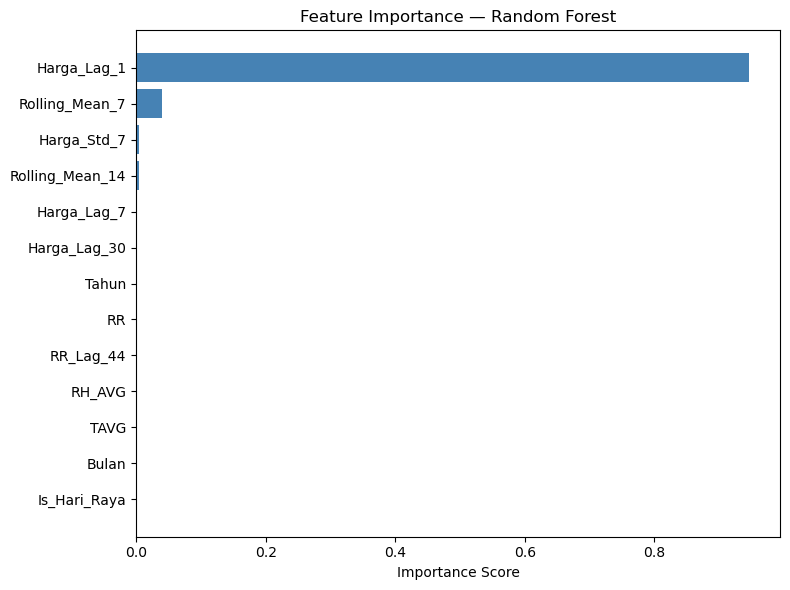

In [16]:
# [Evaluasi] Feature importance Random Forest
importance = pd.DataFrame({
    'Fitur':      feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance['Fitur'], importance['Importance'], color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150)
plt.show()

## 11. Simpan Model Final

In [ ]:
# [Export] Simpan model, scaler, dan feature_cols untuk deployment
joblib.dump(rf_model,     'model_rf_rica_manado_final.pkl')
joblib.dump(scaler,       'scaler_rica_manado_final.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')

print("File tersimpan:")
print("  model_rf_rica_manado_final.pkl")
print("  scaler_rica_manado_final.pkl")
print("  feature_cols.pkl")